In [29]:
import numpy as np

In [15]:
import pandas as pd
import os

os.getcwd()
path = '/Users/iriskwon/Documents/Spr26/MLMA Final Project/'

df = pd.read_csv(os.path.join(path, 'merged_data.csv'))

/var/folders/jc/r13c712s6dj2g5bnkv832wk40000gn/T/ipykernel_18658/4289001169.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, 'merged_data.csv'))


In [16]:
df.head()

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0


### 0. Visualize class distribution of nurses by stress level!

In [17]:
len(df['id'].unique())
unique_nurses_id = df['id'].unique()
print(unique_nurses_id)

# Convert all IDs to strings to standardize them
df['id'] = df['id'].astype(str)

# Check the unique nurse IDs after standardization
unique_nurses_id = df['id'].unique()
print(f"Number of unique nurse IDs: {len(unique_nurses_id)}")
print(unique_nurses_id)

[15 '15' '5C' '6B' '6D' '7A' '7E' '83' 83 '8B' '94' 94 'BG' 'CE' 'DF' 'E4'
 'EG' 'F5']
Number of unique nurse IDs: 15
['15' '5C' '6B' '6D' '7A' '7E' '83' '8B' '94' 'BG' 'CE' 'DF' 'E4' 'EG'
 'F5']


In [18]:
# Assuming the dataset has columns 'nurse_id' and 'label'
# Group by nurse and label to count occurrences
label_distribution = df.groupby(['id', 'label']).size().reset_index(name='count')

# Pivot the data for visualization 
pivot_table = label_distribution.pivot(index='id',columns='label', values='count').fillna(0)

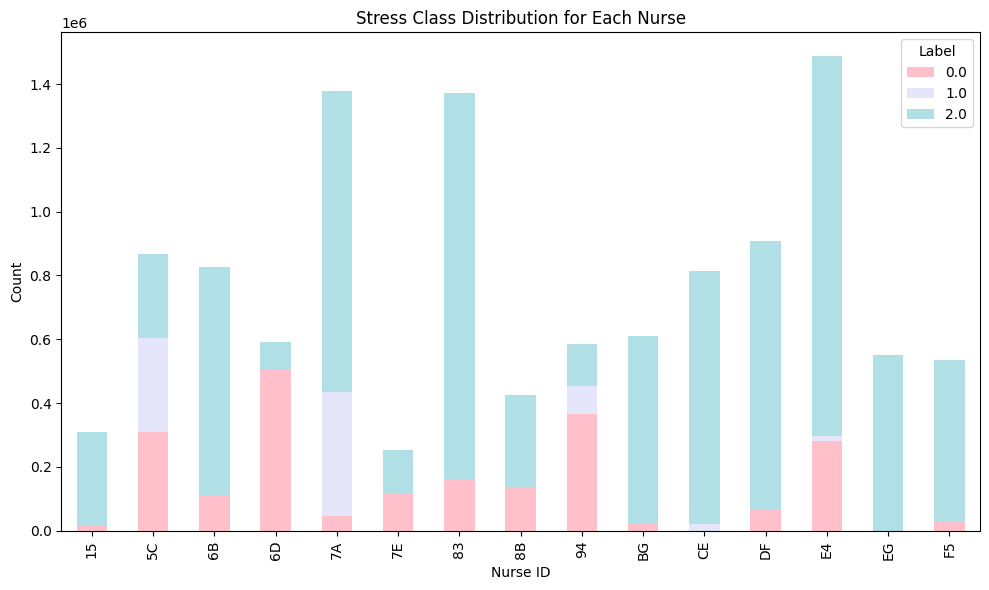

In [19]:
import matplotlib.pyplot as plt 

# Plot the distribution
pivot_table.plot(kind='bar', stacked=True, figsize=(10, 6), color = ['pink','lavender','powderblue'])

plt.title('Stress Class Distribution for Each Nurse')
plt.xlabel('Nurse ID')
plt.ylabel('Count')
plt.legend(title='Label')
plt.tight_layout()

# Show the plot
plt.show()

In [20]:
df.isna().sum()

X           0
Y           0
Z           0
EDA         0
HR          0
TEMP        0
id          0
datetime    0
label       0
dtype: int64

In [21]:
unique_nurses_id

array(['15', '5C', '6B', '6D', '7A', '7E', '83', '8B', '94', 'BG', 'CE',
       'DF', 'E4', 'EG', 'F5'], dtype=object)

In [24]:
df.head()

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0


In [25]:
# Transform datetime 
df['datetime'] = pd.to_datetime(df['datetime'])

In [30]:
np.max(df['datetime']), np.min(df['datetime'])

(Timestamp('2020-12-13 08:01:00'), Timestamp('2020-04-14 22:31:00'))

In [32]:
df.columns

Index(['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP', 'id', 'datetime', 'label'], dtype='object')

In [33]:
features = ['X','Y','Z','EDA','HR','TEMP']

In [ ]:
processed_df = {}

for pid, df_nurse in df.groupby('id'):
    df_nurse = df_nurse.sort_values('datetime').copy()

    # Normalize per person (safe)
    df_nurse[features] = (df_nurse[features] - df_nurse[features].mean()) / (df_nurse[features].std() + 1e-8)

    # Set time index
    df_nurse = df_nurse.set_index('datetime')

    window = '60s'

    # Accelerometer magnitude
    df_nurse['acc_mag'] = np.sqrt(
        df_nurse['X']**2 + df_nurse['Y']**2 + df_nurse['Z']**2
    )

    # Aggregation dictionary
    agg_dict = {
        'HR': ['mean', 'std'],
        'EDA': ['mean', 'std'],
        'TEMP': ['mean', 'std'],
        'acc_mag': ['mean', 'std']
    }

    # Feature aggregation
    features_df = df_nurse.resample(window).agg(agg_dict)
    features_df.columns = ['_'.join(col) for col in features_df.columns]

    # Label aggregation (mode)
    label_df = df_nurse['label'].resample(window).agg(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )

    features_df['label'] = label_df

    # Drop missing
    features_df = features_df.dropna()

    # Time features
    features_df['hour'] = features_df.index.hour
    features_df['hour_sin'] = np.sin(2*np.pi*features_df['hour']/24)
    features_df['hour_cos'] = np.cos(2*np.pi*features_df['hour']/24)

    cols = [col for col in features_df.columns if col != 'label'] + ['label']
    features_df = features_df[cols]

    # Save
    features_df.to_csv(f'data/processed_nurse_{pid}.csv')

    # Store processed version
    processed_df[pid] = features_df

In [44]:
for pid 

AttributeError: 'dict' object has no attribute 'columns'

# other

In [7]:
df['label'].unique()
df['label'].value_counts()

,count
label,
2.0,8540583
0.0,2162246
1.0,806222


In [10]:
label_counts = df['label'].value_counts()
ratio = label_counts[2.0] / label_counts[0.0]
print(f"Ratio of label 2.0 to label 0.0 counts: {ratio}")

Ratio of label 2.0 to label 0.0 counts: 3.9498664814271827


In [11]:
df.groupby('id')['label'].value_counts()

id  label
15  2.0       248703
    0.0        13441
83  2.0      1147516
    0.0       163204
94  0.0       348874
    2.0        87956
    1.0        87458
15  2.0        46987
5C  0.0       309121
    1.0       295685
    2.0       261124
6B  2.0       718027
    0.0       107522
6D  0.0       503041
    2.0        88322
7A  2.0       942743
    1.0       388517
    0.0        46082
7E  2.0       136323
    0.0       117124
83  2.0        62099
8B  2.0       285520
    0.0       138243
94  2.0        44529
    0.0        17279
BG  2.0       587533
    0.0        21122
CE  2.0       794886
    1.0        19201
DF  2.0       842886
    0.0        65282
E4  2.0      1191320
    0.0       281190
    1.0        15361
EG  2.0       549124
F5  2.0       504985
    0.0        30721
Name: count, dtype: int64

In [1]:
df.groupby('label')[['HR','EDA','TEMP']].mean()

NameError: name 'df' is not defined